In [1]:
#importamos la librerías 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
# cargar datos
flight_df = pd.read_csv("../data/customer_flight_activity.csv")
loyalty_df = pd.read_csv("../data/customer_loyalty_history.csv")

# Fase 1
## 1. Exploración 

In [ ]:
# comprobar las primeras filas de los  dataframe
flight_df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [4]:
loyalty_df.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [5]:
# Ver el tamaño de cada dataset
print("Dimensiones de flight_df:", flight_df.shape)
print("Dimensiones de loyalty_df:", loyalty_df.shape)

Dimensiones de flight_df: (405624, 10)
Dimensiones de loyalty_df: (16737, 16)


In [6]:
# Ver estructura y tipos de datos
flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [7]:
loyalty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [8]:
# Revisar valores nulos
flight_df.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [9]:
loyalty_df.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [10]:
# revisar duplicados

print("Duplicados en flight_df:", flight_df.duplicated().sum())
print("Duplicados en loyalty_df:", loyalty_df.duplicated().sum())

Duplicados en flight_df: 1864
Duplicados en loyalty_df: 0


In [11]:
# Estadísticas básicas de variables numéricas
flight_df.describe()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000
mean,550037.873084,2017.500000,6.500000,4.115052,1.031805,5.146858,1208.880059,123.692721,30.696872,2.484503
std,258935.286969,0.500001,3.452057,5.225518,2.076869,6.521227,1433.155320,146.599831,125.486049,10.150038
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326961.000000,2017.000000,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550834.000000,2017.500000,6.500000,1.000000,0.000000,1.000000,488.000000,50.000000,0.000000,0.000000
75%,772194.000000,2018.000000,9.250000,8.000000,1.000000,10.000000,2336.000000,239.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000


In [12]:
loyalty_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


In [13]:
# Revisar variables categóricas
loyalty_df.describe(include="object").T

,count,unique,top,freq
Country,16737,1,Canada,16737
Province,16737,11,Ontario,5404
City,16737,29,Toronto,3351
Postal Code,16737,55,V6E 3D9,911
Gender,16737,2,Female,8410
Education,16737,5,Bachelor,10475
Marital Status,16737,3,Married,9735
Loyalty Card,16737,3,Star,7637
Enrollment Type,16737,2,Standard,15766


In [14]:
for col in ["Gender", "Education", "Marital Status", "Loyalty Card", "Province"]:
    print(f"\nColumna: {col}")
    print(loyalty_df[col].value_counts(dropna=False))


Columna: Gender
Gender
Female    8410
Male      8327
Name: count, dtype: int64

Columna: Education
Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

Columna: Marital Status
Marital Status
Married     9735
Single      4484
Divorced    2518
Name: count, dtype: int64

Columna: Loyalty Card
Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

Columna: Province
Province
Ontario                 5404
British Columbia        4409
Quebec                  3300
Alberta                  969
Manitoba                 658
New Brunswick            636
Nova Scotia              518
Saskatchewan             409
Newfoundland             258
Yukon                    110
Prince Edward Island      66
Name: count, dtype: int64



### Problemas detectados:

- Duplicados en flight_df: 1864 filas repetidas.
- Valores nulos en Salary: 4238 registros faltantes.
- Valores nulos en columnas de cancelación: probablemente representan clientes activos, no errores.
- Valores negativos en Salary: hay salarios negativos, lo que indica datos incoherentes.
- Posibles valores atípicos en variables como Salary, CLV, Distance o Flights Booked.

unir los datasets

In [15]:
df = flight_df.merge(loyalty_df, on="Loyalty Number", how="left")

In [16]:
df.shape

(405624, 25)

In [17]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


In [18]:
df.isnull().sum().sort_values(ascending=False)

Cancellation Month             355560
Cancellation Year              355560
Salary                         102672
Year                                0
Flights with Companions             0
Total Flights                       0
Month                               0
Flights Booked                      0
Loyalty Number                      0
Points Redeemed                     0
Points Accumulated                  0
Distance                            0
Dollar Cost Points Redeemed         0
City                                0
Postal Code                         0
Province                            0
Country                             0
Education                           0
Gender                              0
Marital Status                      0
Loyalty Card                        0
Enrollment Type                     0
CLV                                 0
Enrollment Month                    0
Enrollment Year                     0
dtype: int64

## 2. Limpieza 

In [19]:
# Revisar duplicados
print("Duplicados en df:", df.duplicated().sum())

Duplicados en df: 1864


In [21]:
# eliminamos los duplicados
df = df.drop_duplicates()
print("Duplicados después de limpiar:", df.duplicated().sum())

Duplicados después de limpiar: 0


In [24]:
# Revisar nulos
print("Nulos en df:", df.isnull().sum().sum())
df.isnull().sum().sort_values(ascending=False)

Nulos en df: 810480


Cancellation Month             354110
Cancellation Year              354110
Salary                         102260
Year                                0
Flights with Companions             0
Total Flights                       0
Month                               0
Flights Booked                      0
Loyalty Number                      0
Points Redeemed                     0
Points Accumulated                  0
Distance                            0
Dollar Cost Points Redeemed         0
City                                0
Postal Code                         0
Province                            0
Country                             0
Education                           0
Gender                              0
Marital Status                      0
Loyalty Card                        0
Enrollment Type                     0
CLV                                 0
Enrollment Month                    0
Enrollment Year                     0
dtype: int64

In [25]:
# tratar los nulos por las columnas
# tratar nulos de cancelación
df["Cancelled"] = df["Cancellation Year"].notnull()  # creamos una nueva columna (booleana)

In [26]:
# tratar nulos en Salary
df["Salary"].isnull().sum()

np.int64(102260)

In [27]:
# revisar salarios negativos
(df["Salary"] < 0).sum()

np.int64(480)

In [28]:
# convertimos los salarios negativos a nulos
df.loc[df["Salary"] < 0, "Salary"] = np.nan


Verificamos coherencia de variables numéricas

In [31]:
print("Flights Booked negativos:", (df["Flights Booked"] < 0).sum())
print("Distance negativa:", (df["Distance"] < 0).sum())
print("Points Accumulated negativos:", (df["Points Accumulated"] < 0).sum())
print("Points Redeemed negativos:", (df["Points Redeemed"] < 0).sum())
print("CLV negativo:", (df["CLV"] < 0).sum())

Flights Booked negativos: 0
Distance negativa: 0
Points Accumulated negativos: 0
Points Redeemed negativos: 0
CLV negativo: 0


In [33]:
df.tail()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Cancelled
405619,999902,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN,False
405620,999911,2018,12,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,8,NaN,NaN,False
405621,999940,2018,12,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,7,NaN,NaN,False
405622,999982,2018,12,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,7,NaN,NaN,False
405623,999986,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Ottawa,K1F 2R2,Female,Bachelor,46594.0,Married,Nova,8257.01,2018 Promotion,2018,2,NaN,NaN,False


In [34]:
(df["Total Flights"] < df["Flights Booked"]).sum()

np.int64(0)

In [35]:
(df["Flights with Companions"] > df["Total Flights"]).sum()

np.int64(0)

In [37]:
# Limpiar columnas de texto
text_cols = [
    "Country",
    "Province",
    "City",
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type",
]

for col in text_cols:
    df[col] = df[col].str.strip()

In [38]:
# ajustar tipo de datos
# Convertir a tipo entero las columnas sin nulos
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Enrollment Year"] = df["Enrollment Year"].astype(int)
df["Enrollment Month"] = df["Enrollment Month"].astype(int)

In [39]:
# columnas de cancelación
df["Cancellation Year"] = df["Cancellation Year"].astype("Int64")
df["Cancellation Month"] = df["Cancellation Month"].astype("Int64")

In [40]:
# Comprobar el resultado final de la limpieza
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403760 entries, 0 to 405623
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               403760 non-null  int64  
 1   Year                         403760 non-null  int64  
 2   Month                        403760 non-null  int64  
 3   Flights Booked               403760 non-null  int64  
 4   Flights with Companions      403760 non-null  int64  
 5   Total Flights                403760 non-null  int64  
 6   Distance                     403760 non-null  int64  
 7   Points Accumulated           403760 non-null  float64
 8   Points Redeemed              403760 non-null  int64  
 9   Dollar Cost Points Redeemed  403760 non-null  int64  
 10  Country                      403760 non-null  object 
 11  Province                     403760 non-null  object 
 12  City                         403760 non-null  object 
 13  Post

In [41]:
df.isnull().sum().sort_values(ascending=False)

Cancellation Month             354110
Cancellation Year              354110
Salary                         102740
Month                               0
Flights with Companions             0
Total Flights                       0
Distance                            0
Flights Booked                      0
Loyalty Number                      0
Year                                0
Dollar Cost Points Redeemed         0
Points Redeemed                     0
Points Accumulated                  0
Country                             0
Postal Code                         0
Gender                              0
City                                0
Province                            0
Marital Status                      0
Education                           0
Loyalty Card                        0
CLV                                 0
Enrollment Year                     0
Enrollment Type                     0
Enrollment Month                    0
Cancelled                           0
dtype: int64

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.0,326699.0,550598.0,772152.0,999986.0
Year,403760.0,2017.500352,0.5,2017.0,2017.0,2018.0,2018.0,2018.0
Month,403760.0,6.501335,3.451982,1.0,4.0,7.0,10.0,12.0
Flights Booked,403760.0,4.13405,5.230064,0.0,0.0,1.0,8.0,21.0
Flights with Companions,403760.0,1.036569,2.080472,0.0,0.0,0.0,1.0,11.0
Total Flights,403760.0,5.170619,6.526858,0.0,0.0,1.0,10.0,32.0
Distance,403760.0,1214.460979,1434.098521,0.0,0.0,525.0,2342.0,6293.0
Points Accumulated,403760.0,124.263761,146.696179,0.0,0.0,53.0,240.0,676.5
Points Redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.0,0.0,0.0,0.0,71.0


In [44]:
df = df.reset_index(drop=True)
df_clean = df.copy()

In [45]:
# lo convierto en CVS
df_clean.to_csv("../data/df_clean.csv", index=False)

# Fase 2: Análisis estadístico

In [46]:
# Análisis de variables numéricas
# selecciionamos variables numéricas
num_cols = df_clean.select_dtypes(include=["number"]).columns
num_cols

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed',
       'Salary', 'CLV', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='object')

 Estadística descriptiva básica:

In [ ]:

df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.0,326699.0,550598.0,772152.0,999986.0
Year,403760.0,2017.500352,0.5,2017.0,2017.0,2018.0,2018.0,2018.0
Month,403760.0,6.501335,3.451982,1.0,4.0,7.0,10.0,12.0
Flights Booked,403760.0,4.13405,5.230064,0.0,0.0,1.0,8.0,21.0
Flights with Companions,403760.0,1.036569,2.080472,0.0,0.0,0.0,1.0,11.0
Total Flights,403760.0,5.170619,6.526858,0.0,0.0,1.0,10.0,32.0
Distance,403760.0,1214.460979,1434.098521,0.0,0.0,525.0,2342.0,6293.0
Points Accumulated,403760.0,124.263761,146.696179,0.0,0.0,53.0,240.0,676.5
Points Redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.0,0.0,0.0,0.0,71.0


In [48]:
# Añadir media, mediana, moda y desviación estándar de forma más clara
estadisticas_numericas = pd.DataFrame(
    {
        "media": df_clean[num_cols].mean(),
        "mediana": df_clean[num_cols].median(),
        "moda": df_clean[num_cols].mode().iloc[0],
        "desviacion_estandar": df_clean[num_cols].std(),
        "minimo": df_clean[num_cols].min(),
        "maximo": df_clean[num_cols].max(),
    }
)

estadisticas_numericas

,media,mediana,moda,desviacion_estandar,minimo,maximo
Loyalty Number,549875.383713,550598.0,617489.0,258961.514684,100018.0,999986.0
Year,2017.500352,2018.0,2018.0,0.5,2017.0,2018.0
Month,6.501335,7.0,11.0,3.451982,1.0,12.0
Flights Booked,4.13405,1.0,0.0,5.230064,0.0,21.0
Flights with Companions,1.036569,0.0,0.0,2.080472,0.0,11.0
Total Flights,5.170619,1.0,0.0,6.526858,0.0,32.0
Distance,1214.460979,525.0,0.0,1434.098521,0.0,6293.0
Points Accumulated,124.263761,53.0,0.0,146.696179,0.0,676.5
Points Redeemed,30.838587,0.0,0.0,125.758002,0.0,876.0
Dollar Cost Points Redeemed,2.495973,0.0,0.0,10.172033,0.0,71.0


Identificación de valores atípicos:

In [49]:
# Función para detectar los valores atípicos utilizando el método del rango intercuartílico (IQR)


def detectar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)
    ]

    return outliers

In [50]:
# Aplicarlo a variables relevantes
variables_outliers = [
    "Flights Booked",
    "Total Flights",
    "Distance",
    "Points Accumulated",
    "Salary",
    "CLV",
]

for col in variables_outliers:
    outliers = detectar_outliers_iqr(df_clean.dropna(subset=[col]), col)
    print(f"{col}: {outliers.shape[0]} valores atípicos")

Flights Booked: 528 valores atípicos
Total Flights: 1984 valores atípicos
Distance: 125 valores atípicos
Points Accumulated: 112 valores atípicos
Salary: 12761 valores atípicos
CLV: 35941 valores atípicos


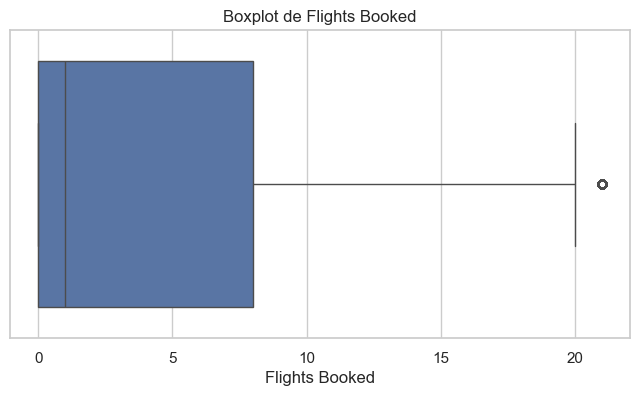

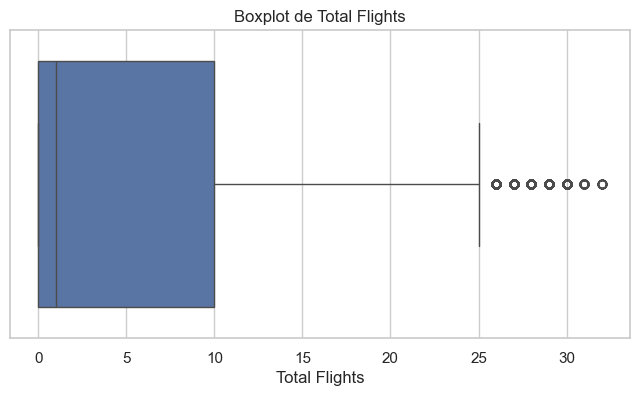

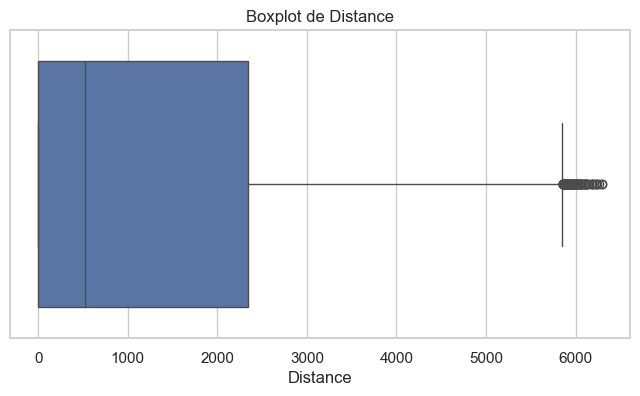

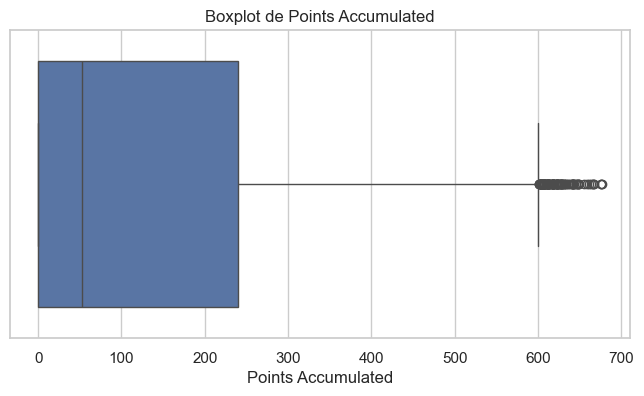

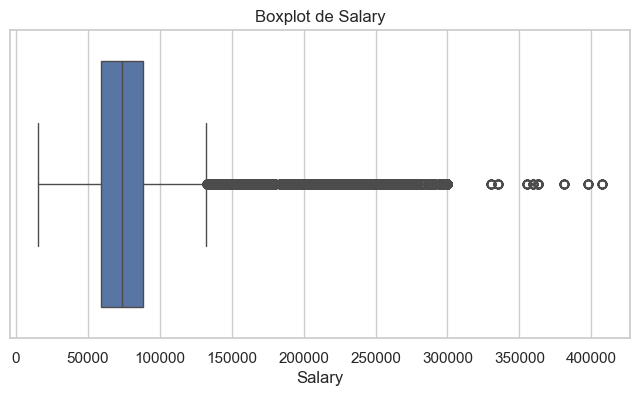

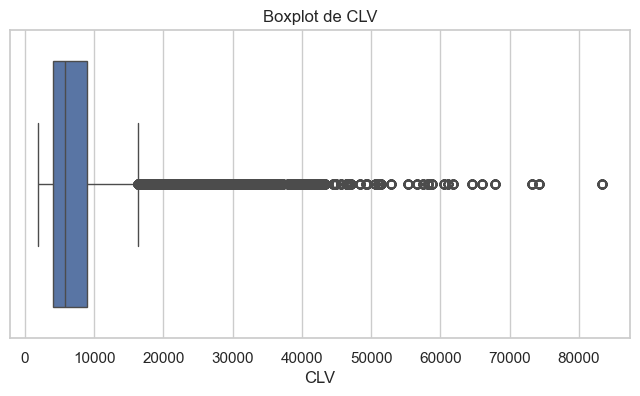

In [51]:
# Visualizar con boxplots
for col in variables_outliers:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

La existencia de numerosos valores atípicos en Salary y CLV sugiere que hay clientes muy distintos entre sí en términos de ingresos y valor para la empresa. Esto puede reflejar una base de clientes heterogénea.

## Correlación entre variables numéricas

In [52]:
# Matriz de correlación
corr_matrix = df_clean[num_cols].corr()
corr_matrix

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
Loyalty Number,1.000000,0.000391,0.000199,-0.002280,-0.003069,-0.002805,-0.001779,-0.001792,0.000647,0.000641,0.012819,-0.000625,0.008209,0.004877,0.007354,0.033378
Year,0.000391,1.000000,-0.000025,0.044121,0.021327,0.042153,0.055767,0.074910,0.017503,0.017495,0.000078,0.000187,0.000500,-0.000243,-0.000044,0.000431
Month,0.000199,-0.000025,1.000000,0.082137,0.064486,0.086373,0.076321,0.054066,0.019361,0.019267,0.000045,0.000051,0.000211,-0.000120,0.000032,0.000099
Flights Booked,-0.002280,0.044121,0.082137,1.000000,0.501698,0.961233,0.766748,0.759547,0.187638,0.187647,0.005725,-0.002847,-0.153305,-0.031550,0.316053,0.064853
Flights with Companions,-0.003069,0.021327,0.064486,0.501698,1.000000,0.720773,0.517188,0.510284,0.334000,0.334060,0.002084,-0.002510,-0.096835,-0.019639,0.220471,0.049511
Total Flights,-0.002805,0.042153,0.086373,0.961233,0.720773,1.000000,0.779262,0.771291,0.256821,0.256848,0.005253,-0.003081,-0.153712,-0.031542,0.316461,0.066162
Distance,-0.001779,0.055767,0.076321,0.766748,0.517188,0.779262,1.000000,0.994546,0.223707,0.223728,0.007777,-0.004132,-0.165141,-0.034449,0.330539,0.070337
Points Accumulated,-0.001792,0.074910,0.054066,0.759547,0.510284,0.771291,0.994546,1.000000,0.222674,0.222707,0.007603,-0.000942,-0.164520,-0.033923,0.332410,0.069457
Points Redeemed,0.000647,0.017503,0.019361,0.187638,0.334000,0.256821,0.223707,0.222674,1.000000,0.999972,0.002486,-0.000265,-0.047759,-0.008680,0.112523,0.026184
Dollar Cost Points Redeemed,0.000641,0.017495,0.019267,0.187647,0.334060,0.256848,0.223728,0.222707,0.999972,1.000000,0.002479,-0.000238,-0.047808,-0.008683,0.112596,0.026154


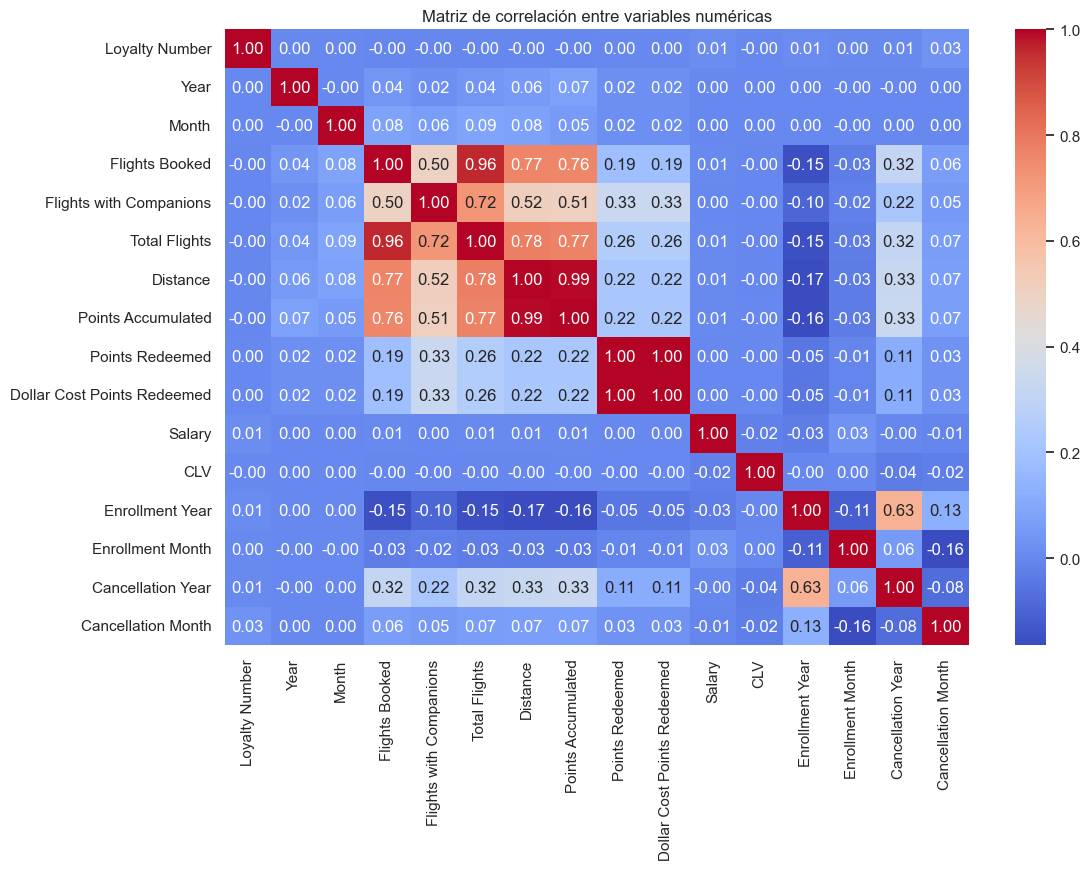

In [53]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()



La matriz de correlación muestra relaciones fuertes entre variables que están directamente conectadas con la actividad de vuelo. Destaca especialmente la relación entre `Distance` y `Points Accumulated`, así como entre `Flights Booked` y `Total Flights`.

Por el contrario, variables como `Salary` y `CLV` presentan correlaciones muy bajas con la mayoría de variables operativas, por lo que no parece existir una relación lineal clara entre estas y la actividad mensual de vuelo.

Análisis de variables categóricas

In [54]:
# Seleccionar columnas categóricas relevantes
cat_cols = [
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Province",
    "Enrollment Type",
]

In [55]:
# Frecuencias absolutas
for col in cat_cols:
    print(f"\nFrecuencias de {col}")
    print(df_clean[col].value_counts())


Frecuencias de Gender
Gender
Female    202757
Male      201003
Name: count, dtype: int64

Frecuencias de Education
Education
Bachelor                252567
College                 102260
High School or Below     18915
Doctor                   17731
Master                   12287
Name: count, dtype: int64

Frecuencias de Marital Status
Marital Status
Married     234845
Single      108153
Divorced     60762
Name: count, dtype: int64

Frecuencias de Loyalty Card
Loyalty Card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64

Frecuencias de Province
Province
Ontario                 130258
British Columbia        106442
Quebec                   79573
Alberta                  23360
Manitoba                 15900
New Brunswick            15352
Nova Scotia              12507
Saskatchewan              9861
Newfoundland              6244
Yukon                     2679
Prince Edward Island      1584
Name: count, dtype: int64

Frecuencias de Enrollment Type
Enrollment T

In [56]:
# Frecuencias relativas en porcentaje

for col in cat_cols:
    print(f"\nPorcentajes de {col}")
    print(round(df_clean[col].value_counts(normalize=True) * 100, 2))


Porcentajes de Gender
Gender
Female    50.22
Male      49.78
Name: proportion, dtype: float64

Porcentajes de Education
Education
Bachelor                62.55
College                 25.33
High School or Below     4.68
Doctor                   4.39
Master                   3.04
Name: proportion, dtype: float64

Porcentajes de Marital Status
Marital Status
Married     58.16
Single      26.79
Divorced    15.05
Name: proportion, dtype: float64

Porcentajes de Loyalty Card
Loyalty Card
Star      45.51
Nova      33.90
Aurora    20.59
Name: proportion, dtype: float64

Porcentajes de Province
Province
Ontario                 32.26
British Columbia        26.36
Quebec                  19.71
Alberta                  5.79
Manitoba                 3.94
New Brunswick            3.80
Nova Scotia              3.10
Saskatchewan             2.44
Newfoundland             1.55
Yukon                    0.66
Prince Edward Island     0.39
Name: proportion, dtype: float64

Porcentajes de Enrollment Type
E

In [57]:
clientes_unicos = df_clean.drop_duplicates(subset="Loyalty Number")

for col in cat_cols:
    print(f"\nFrecuencias de {col}")
    print(clientes_unicos[col].value_counts())

for col in cat_cols:
    print(f"\nPorcentajes de {col}")
    print(round(clientes_unicos[col].value_counts(normalize=True) * 100, 2))


Frecuencias de Gender
Gender
Female    8410
Male      8327
Name: count, dtype: int64

Frecuencias de Education
Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

Frecuencias de Marital Status
Marital Status
Married     9735
Single      4484
Divorced    2518
Name: count, dtype: int64

Frecuencias de Loyalty Card
Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

Frecuencias de Province
Province
Ontario                 5404
British Columbia        4409
Quebec                  3300
Alberta                  969
Manitoba                 658
New Brunswick            636
Nova Scotia              518
Saskatchewan             409
Newfoundland             258
Yukon                    110
Prince Edward Island      66
Name: count, dtype: int64

Frecuencias de Enrollment Type
Enrollment Type
Standard          15766
2018 Promotion 



El análisis de frecuencias permite identificar algunas categorías predominantes dentro de la base analizada. En educación destaca `Bachelor`, en estado civil `Married`, en tipo de tarjeta `Star` y en provincia `Ontario`.

Además, la distribución por género es bastante equilibrada, por lo que no se observan diferencias muy marcadas entre hombres y mujeres en el conjunto de registros.

# Fase 3. Visualización 

## 1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?


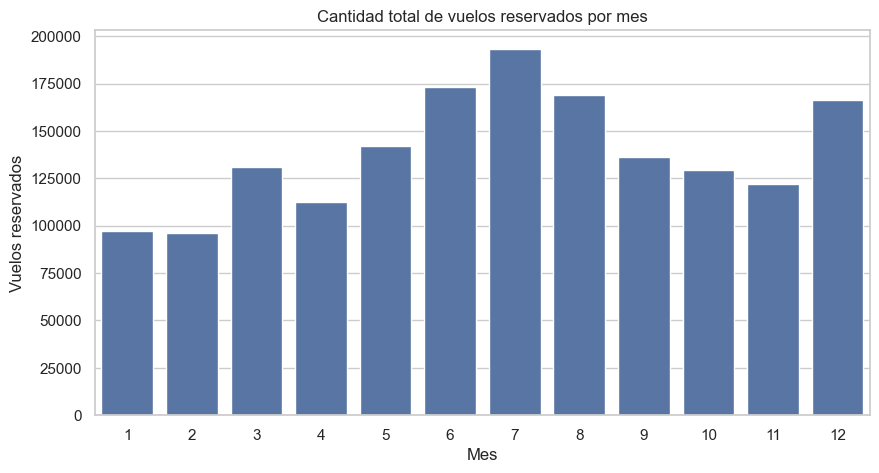

In [60]:
# agrupar por Month y sumar flight booked

flights_per_month = df_clean.groupby("Month")["Flights Booked"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=flights_per_month, x="Month", y="Flights Booked")
plt.title("Cantidad total de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Vuelos reservados")
plt.show()

La cantidad de vuelos reservados no se distribuye de forma uniforme a lo largo del año. Se observa un aumento progresivo desde comienzos de año hasta alcanzar el máximo en julio, lo que sugiere una mayor actividad de reserva en los meses de verano.

Después de julio, el volumen de reservas desciende durante los meses siguientes, aunque vuelve a repuntar en diciembre. Esto puede indicar un efecto estacional, con mayor demanda en periodos vacacionales como verano y final de año.

## 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes?

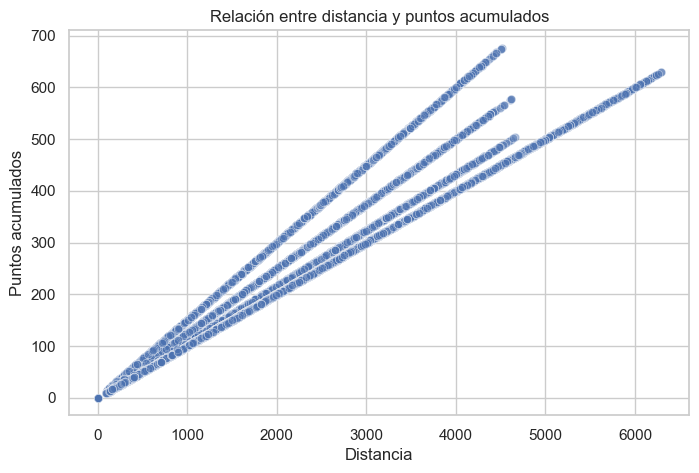

In [61]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="Distance", y="Points Accumulated", alpha=0.5)
plt.title("Relación entre distancia y puntos acumulados")
plt.xlabel("Distancia")
plt.ylabel("Puntos acumulados")
plt.show()

La gráfica muestra una relación positiva clara entre la distancia y los puntos acumulados. Esto indica que, en general, cuanto mayor es la distancia volada, mayor es la cantidad de puntos que recibe el cliente.

## 3. ¿Cuál es la distribución de los clientes por provincia o estado?

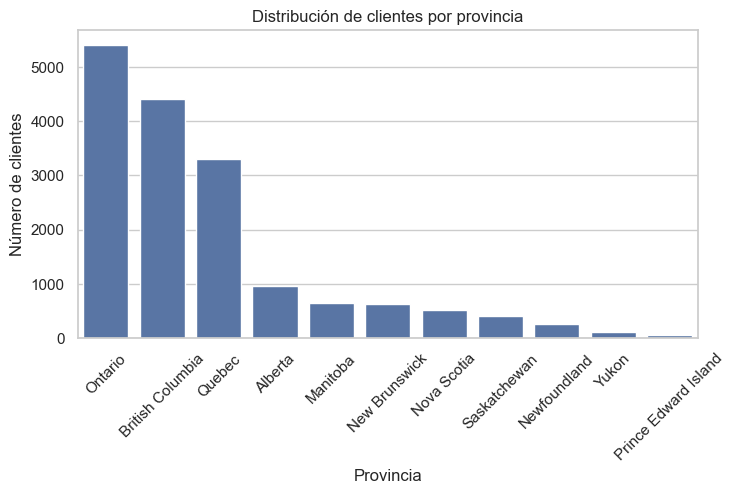

In [63]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=clientes_unicos,
    x="Province",
    order=clientes_unicos["Province"].value_counts().index,
)
plt.title("Distribución de clientes por provincia")
plt.xlabel("Provincia")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()


La mayor parte de los clientes se concentra en Ontario, British Columbia y Quebec. Por el contrario, otras provincias como Yukon y Prince Edward Island tienen una presencia muy baja. Esto muestra una distribución geográfica desigual de la base de clientes.

## 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

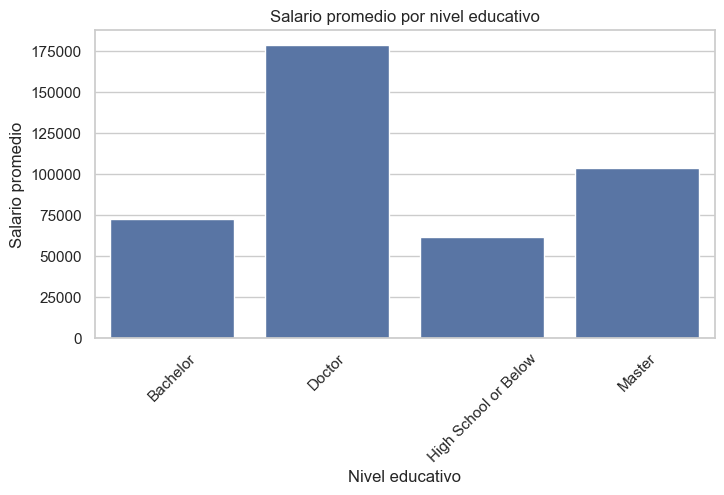

In [65]:
# usamos clientes únicos  y mejor quitando nulos del salario
salary_education = (
    clientes_unicos.dropna(subset=["Salary"])
    .groupby("Education", as_index=False)["Salary"]
    .mean()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=salary_education, x="Education", y="Salary")
plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)
plt.show()

El salario promedio varía de forma clara según el nivel educativo. El grupo con mayor salario medio es `Doctor`, seguido de `Master`, mientras que `Bachelor` y `High School or Below` presentan promedios más bajos. En general, la gráfica sugiere que los niveles educativos más altos tienden a asociarse con salarios promedio más elevados.

No aparece la categoría `College` en la gráfica, lo que probablemente se debe a la ausencia de valores válidos de salario en ese grupo tras el filtrado de nulos realizado para este análisis.

## 5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

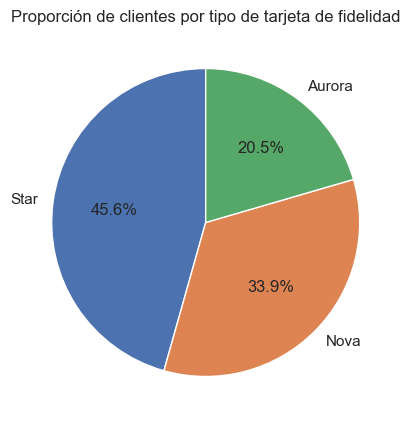

In [67]:
card_counts = clientes_unicos["Loyalty Card"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(card_counts, labels=card_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Proporción de clientes por tipo de tarjeta de fidelidad")
plt.show()


La distribución de clientes por tipo de tarjeta de fidelidad muestra que `Star` es la categoría más frecuente, con un 45.6% del total. Le sigue `Nova`, con un 33.9%, mientras que `Aurora` representa la proporción más baja, con un 20.5%.

Esto indica que la mayoría de los clientes se concentra en los niveles más comunes del programa, mientras que una parte menor pertenece a la categoría `Aurora`.

## 6. ¿Cómo se distribuyen los clientes según su estado civil y género?

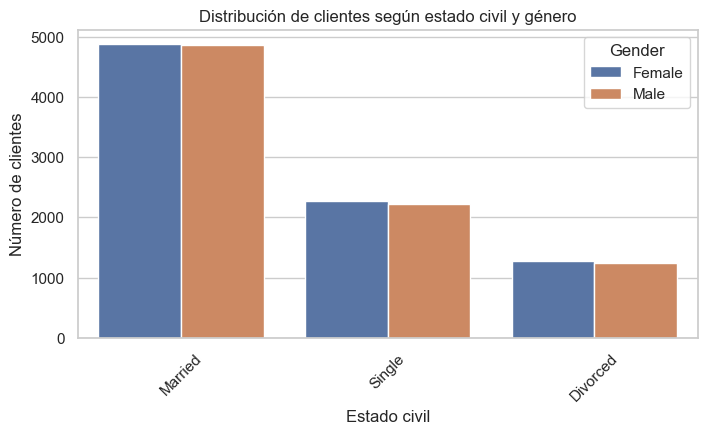

In [69]:
plt.figure(figsize=(8, 4))
sns.countplot(data=clientes_unicos, x="Marital Status", hue="Gender")
plt.title("Distribución de clientes según estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

La categoría `Married` concentra el mayor número de clientes, seguida de `Single` y `Divorced`. En los tres casos, la distribución entre mujeres y hombres es muy similar, por lo que no se observan diferencias relevantes por género.

# Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo


Preparación de datos 

In [ ]:

edu_flights = df_clean[["Flights Booked", "Education"]].dropna()
edu_flights.head()

,Flights Booked,Education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor


In [74]:
edu_flights.shape

(403760, 2)

In [75]:
edu_flights["Education"].value_counts()

Education
Bachelor                252567
College                 102260
High School or Below     18915
Doctor                   17731
Master                   12287
Name: count, dtype: int64

Análisis descriptivo por nivel educativo 

In [76]:
# agrupamos por educación y calculamos la estadística básica
edu_stats = (
    edu_flights.groupby("Education")["Flights Booked"]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
)
edu_stats

,Education,mean,std,median,count
0,Bachelor,4.110288,5.221671,1.0,252567
1,College,4.169744,5.246040,1.0,102260
2,Doctor,4.175512,5.256971,1.0,17731
3,High School or Below,4.176209,5.239267,1.0,18915
4,Master,4.200700,5.213956,1.0,12287


In [77]:
# lo ordenamos por la media para verlo mas claro
edu_stats = edu_stats.sort_values(by="mean", ascending=False)
edu_stats

,Education,mean,std,median,count
4,Master,4.200700,5.213956,1.0,12287
3,High School or Below,4.176209,5.239267,1.0,18915
2,Doctor,4.175512,5.256971,1.0,17731
1,College,4.169744,5.246040,1.0,102260
0,Bachelor,4.110288,5.221671,1.0,252567


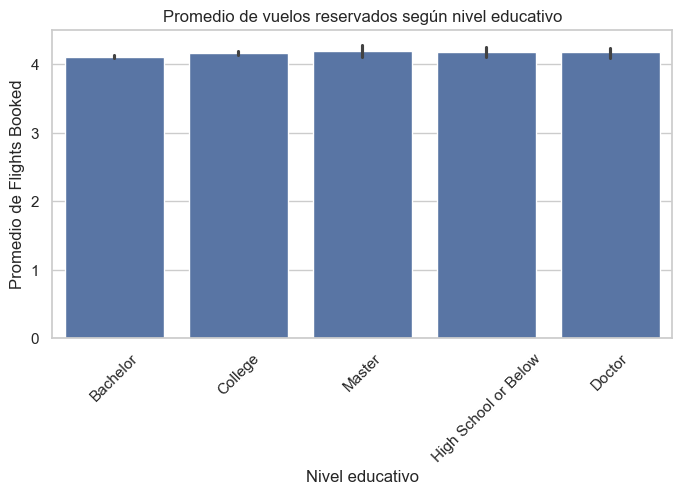

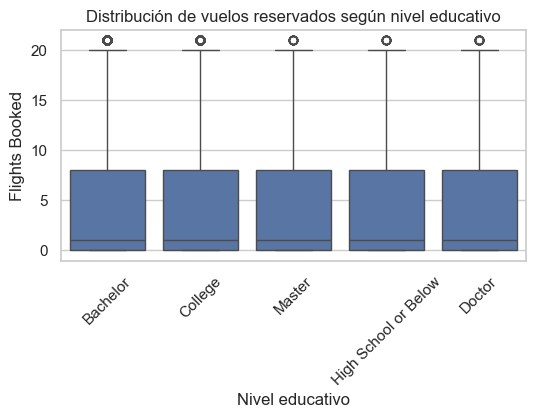

In [82]:
# gráfico de barras con el promedio
plt.figure(figsize=(8, 4))
sns.barplot(data=edu_flights, x="Education", y="Flights Booked", estimator="mean")
plt.title("Promedio de vuelos reservados según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Promedio de Flights Booked")
plt.xticks(rotation=45)
plt.show()

# Boxplot 
plt.figure(figsize=(6, 3))
sns.boxplot(data=edu_flights, x="Education", y="Flights Booked")
plt.title("Distribución de vuelos reservados según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Flights Booked")
plt.xticks(rotation=45)
plt.show()